In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [137]:
df = pd.read_excel("amazon_laptop_2023.xlsx")

In [138]:
print(df.columns.to_list())
print(len(df.columns.to_list()))
print(df.describe())

['brand', 'model', 'screen_size', 'color', 'harddisk', 'cpu', 'ram', 'OS', 'special_features', 'graphics', 'graphics_coprocessor', 'cpu_speed', 'rating', 'price']
14
            rating
count  2174.000000
mean      4.086891
std       1.165337
min       1.000000
25%       4.000000
50%       4.500000
75%       5.000000
max       5.000000


In [142]:
#Drop all empty rows and columns
# df.dropna(how="all", inplace=True)
# df.dropna(axis=1, how="all", inplace=True)
df.drop_duplicates(ignore_index=True, inplace=True)

In [143]:
print(df.dtypes)

brand                    object
model                    object
screen_size              object
color                    object
harddisk                 object
cpu                      object
ram                      object
OS                       object
special_features         object
graphics                 object
graphics_coprocessor     object
cpu_speed                object
rating                  float64
price                    object
dtype: object


In [145]:
#Percent of each column that is empty
print((df.isna().sum() / df.shape[0])*100)
print(df.shape[0])

brand                    0.000000
model                    4.984779
screen_size              1.065449
color                   21.232877
harddisk                 6.849315
cpu                      3.767123
ram                      2.207002
OS                       0.989346
special_features        34.512938
graphics                 2.359209
graphics_coprocessor    60.426180
cpu_speed               87.442922
rating                  60.388128
price                    0.190259
dtype: float64
2628


In [110]:
#brand, model and color don't affect the performance of a laptop and aren't factored into recommendations 
#special_features are has a lot of missing values and a lot of inconsistent and redundant information
#Most of the values in rating are missing and rating is subject to bias and unknown circumstances, may bias recommendations negatively
unused_columns = ['color', 'special_features', 'rating']
df_d = df.drop(unused_columns, axis=1)
print(df_d.columns.to_list())

['brand', 'model', 'screen_size', 'harddisk', 'cpu', 'ram', 'OS', 'graphics', 'graphics_coprocessor', 'cpu_speed', 'price']


In [111]:
features_cat = ['brand', 'model', 'cpu', 'OS', 'graphics', 'graphics_coprocessor']
features_num = ['screen_size', 'harddisk', 'ram', 'cpu_speed', 'price']

In [112]:
df_d[features_cat] = df_d[features_cat].fillna('NA')
df_d[features_num] = df_d[features_num].fillna(np.nan)
df_d

,brand,model,screen_size,harddisk,cpu,ram,OS,graphics,graphics_coprocessor,cpu_speed,price
0,HP,EliteBook 840,14 Inches,256 GB,Core i5 6200U,16 GB,Windows 10 Pro,Integrated,NA,NaN,"$1,000.00"
1,Dell,Inspiron 15 3530,15.6 Inches,2 TB,Core i7 Family,64 GB,Windows 11 Home,Integrated,Intel Iris Xe Graphics,NaN,"$1,000.00"
2,Dell,Vostro 3510 Laptop,15.6 Inches,1000 GB,Core i7,32 GB,Windows 10 Home,Integrated,NA,NaN,"$1,000.99"
3,Dell,Inspiron 7420 2-in-1,14 Inches,2000 GB,Core i5,64 GB,Windows 11 Pro,Integrated,Intel Integrated Graphics,NaN,"$1,001.11"
4,MSI,Prestige 14Evo A11MO-217,14 Inches,NaN,Core i7,32 GB,Windows 10,Integrated,Intel Iris Xe Graphics,NaN,"$1,001.18"
...,...,...,...,...,...,...,...,...,...,...,...
4441,Dell,Dell Latitude Rugged 5404,14 Inches,256 GB,Core i7,8 GB,Windows 10 Pro,Integrated,NA,NaN,NaN
4442,HP,HPS13,15 Inches,128 GB,Pentium Other,4 GB,Windows 11 S,Integrated,NA,NaN,NaN
4443,Microsoft,Surface Laptop Go 2,12.4 Inches,256 GB,Intel Core i5-1135G7,8 GB,Windows 10 S,Integrated,Intel Iris,NaN,NaN
4444,dell,DELL Latitude 5300,13.3 Inches,512 GB,Core i5 8250U,16 GB,Windows 10 Pro,Integrated,Intel Integrated Graphics,NaN,NaN


In [113]:
def string_clean(val):
    string = str(val)
    if string != 'NA':
        string = string.strip().lower()
    return string

for col in features_cat:
    df_d[col] = df_d[col].apply(string_clean)

In [114]:
df_d

,brand,model,screen_size,harddisk,cpu,ram,OS,graphics,graphics_coprocessor,cpu_speed,price
0,hp,elitebook 840,14 Inches,256 GB,core i5 6200u,16 GB,windows 10 pro,integrated,NA,NaN,"$1,000.00"
1,dell,inspiron 15 3530,15.6 Inches,2 TB,core i7 family,64 GB,windows 11 home,integrated,intel iris xe graphics,NaN,"$1,000.00"
2,dell,vostro 3510 laptop,15.6 Inches,1000 GB,core i7,32 GB,windows 10 home,integrated,NA,NaN,"$1,000.99"
3,dell,inspiron 7420 2-in-1,14 Inches,2000 GB,core i5,64 GB,windows 11 pro,integrated,intel integrated graphics,NaN,"$1,001.11"
4,msi,prestige 14evo a11mo-217,14 Inches,NaN,core i7,32 GB,windows 10,integrated,intel iris xe graphics,NaN,"$1,001.18"
...,...,...,...,...,...,...,...,...,...,...,...
4441,dell,dell latitude rugged 5404,14 Inches,256 GB,core i7,8 GB,windows 10 pro,integrated,NA,NaN,NaN
4442,hp,hps13,15 Inches,128 GB,pentium other,4 GB,windows 11 s,integrated,NA,NaN,NaN
4443,microsoft,surface laptop go 2,12.4 Inches,256 GB,intel core i5-1135g7,8 GB,windows 10 s,integrated,intel iris,NaN,NaN
4444,dell,dell latitude 5300,13.3 Inches,512 GB,core i5 8250u,16 GB,windows 10 pro,integrated,intel integrated graphics,NaN,NaN


In [115]:
def reduce_levels(feat_check, minimum):
    val_counts = df_d[feat_check].value_counts()
    inds = list(val_counts[val_counts.values >= minimum].index)
    df_d[feat_check] = df_d[feat_check].where(df_d[feat_check].isin(inds), 'other')
    print(df_d[feat_check].value_counts())

In [116]:
def print_vals(feature):
    vals = df_d[feature].value_counts()
    print(vals)
    print(vals.index.to_list())

In [117]:
feature = 'cpu'
print_vals(feature)

core i7              828
core i5              605
intel core i5        571
intel core i9        426
intel core i7        395
                    ... 
ryzen 7 2700u          1
amd ryzen 7 5800h      1
intel core 2 quad      1
ryzen 9 7900x          1
core i5 2.3 ghz        1
Name: cpu, Length: 142, dtype: int64
['core i7', 'core i5', 'intel core i5', 'intel core i9', 'intel core i7', 'pentium', 'core i7 family', 'pentium n5000', 'celeron n4000', 'core i9', 'NA', 'celeron', 'amd ryzen 7', 'core i5 family', 'core i3', 'ryzen 7', 'ryzen 5', '8032', 'celeron n', 'intel core i5-1135g7', 'celeron n4020', 'amd r series', 'intel core i3', 'core i3 family', 'amd a series', 'corei7-10750h', 'ryzen 9', 'unknown', 'mediatek mt8183', 'apple m1', 'intel core i7-1165g7', 'intel mobile cpu', 'ryzen 7 5800h', '1.2ghz cortex a8 processor', 'core i3-1005g1', 'core i5-10210u', 'athlon', 'celeron n3350', 'core i7 11800h', 'core i3 1115g4', 'celeron n3450', 'others', 'intel core i5 1145g7', 'ryzen 3 3250u', 

In [118]:
df_d[feature].loc[df_d[feature] == 'unknown'] = 'NA'

values = [3, 5, 7, 9]
for value in values:
    df_d[feature].loc[df_d[feature].str.contains(f'core i{value}', na=False)] = f'core i{value}'
    df_d[feature].loc[df_d[feature].str.contains(f'corei{value}', na=False)] = f'core i{value}'
    df_d[feature].loc[df_d[feature].str.contains(f'ryzen {value}', na=False)] = f'ryzen {value}'

df_d[feature].loc[df_d[feature].str.contains('pentium', na=False)] = 'pentium'
df_d[feature].loc[df_d[feature].str.contains('celeron', na=False)] = 'celeron'

print_vals(feature)

core i7                          1451
core i5                          1287
core i9                           569
pentium                           368
celeron                           264
ryzen 7                           117
NA                                110
core i3                            90
ryzen 5                            40
8032                               19
amd r series                       15
amd a series                       13
ryzen 9                            12
ryzen 3                            12
mediatek mt8183                     9
apple m1                            7
1.2ghz cortex a8 processor          6
intel mobile cpu                    6
athlon                              5
others                              4
intel xeon                          3
mediatek_mt8127                     3
intel atom                          3
intel core m-5y10 processor         3
snapdragon                          3
athlon silver 3050u                 2
core 2 duo  

In [119]:
#Everything with less than 10 is hard to compare without cpu speed info
reduce_levels(feature, 10)

core i7         1451
core i5         1287
core i9          569
pentium          368
celeron          264
ryzen 7          117
NA               110
core i3           90
other             79
ryzen 5           40
8032              19
amd r series      15
amd a series      13
ryzen 9           12
ryzen 3           12
Name: cpu, dtype: int64


In [120]:
feature = 'OS'
print_vals(feature)

windows 11                                                                  1199
windows 11 home                                                              988
windows 11 pro                                                               907
windows 10 pro                                                               453
windows 10 home                                                              446
windows 10                                                                   142
chrome os                                                                    125
NA                                                                            26
mac os                                                                        19
windows 7 professional                                                        16
windows 10 s                                                                  14
windows 11 s                                                                  14
windows 7                   

In [121]:
df_d[feature].loc[df_d[feature] == 'unknown'] = 'NA'
df_d[feature].loc[df_d[feature] == 'no'] = 'NA'
df_d[feature].loc[df_d[feature] == 'pc'] = 'NA'

df_d[feature].loc[df_d[feature] == 'windows 7 pro + 10 pro'] = 'windows 10 pro'
df_d[feature].loc[df_d[feature] == 'windows 10 64 bit-multi-language supports english/spanish/french'] = 'windows 10'
df_d[feature].loc[df_d[feature] == 'windows 10 s, windows 10'] = 'windows 10 s'
df_d[feature].loc[df_d[feature] == 'win 10 multi-language /free upgrade to win 11'] = 'windows 10'
df_d[feature].loc[df_d[feature] == 'mac os x 10.0 cheetah'] = 'mac os'
df_d[feature].loc[df_d[feature] == 'win 11 multi-home'] = 'windows 11 home'
df_d[feature].loc[df_d[feature] == 'windows 7 home'] = 'windows 7'

df_d[feature].loc[df_d[feature].str.contains('windows 8', na=False)] = 'windows 8'

values = [7, 8, 10]
for value in values:
        df_d[feature].loc[df_d[feature].str.contains(f'windows {value} pro', na=False)] = f'windows {value} pro'
        df_d[feature].loc[df_d[feature].str.contains(f'windows {value} home', na=False)] = f'windows {value} home'

df_d[feature].loc[df_d[feature].str.contains('win 10 pro', na=False)] = 'windows 10 pro'
df_d[feature].loc[df_d[feature].str.contains('macos', na=False)] = 'mac os'

print_vals(feature)

windows 11                   1199
windows 11 home               989
windows 11 pro                907
windows 10 pro                487
windows 10 home               449
windows 10                    145
chrome os                     125
mac os                         30
NA                             29
windows 7 pro                  17
windows 10 s                   15
windows 11 s                   14
windows 7                      12
windows 8                      11
windows                         7
windows pro                     2
windows 11 home s               2
windows 11 pro, windows         2
linux                           1
windows 11 home in s mode       1
hp thinpro                      1
windows 7 home                  1
Name: OS, dtype: int64
['windows 11', 'windows 11 home', 'windows 11 pro', 'windows 10 pro', 'windows 10 home', 'windows 10', 'chrome os', 'mac os', 'NA', 'windows 7 pro', 'windows 10 s', 'windows 11 s', 'windows 7', 'windows 8', 'windows', 'windows pr

In [122]:
feature = 'graphics'
print_vals(feature)

integrated                              3021
dedicated                                850
iris xe graphics                          89
NA                                        65
nvidia geforce rtx 4070                   30
                                        ... 
geforce rtx 3070 ti,iris xe graphics       1
rtx 4080                                   1
rtx 2060                                   1
nvidia rtx 4000 ada                        1
nvidia geforce gtx 1650 4gb                1
Name: graphics, Length: 110, dtype: int64
['integrated', 'dedicated', 'iris xe graphics', 'NA', 'nvidia geforce rtx 4070', 'uhd graphics', 'nvidia geforce rtx 3050 ti', 'integrated, dedicated', 'radeon graphics', 'nvidia rtx a3000', 'nvidia geforce rtx 4090', 'nvidia geforce rtx 4060', 'nvidia geforce rtx 3050', 'nvidia geforce rtx 4050', 'nvidia t1200', 't550', 'nvidia geforce rtx a500', 'nvidia rtx a1000', 'nvidia rtx a2000', 'nvidia quadro rtx 3000', 'rtx a2000', 'nvidia geforce rtx 3060', 'rtx a1

In [123]:
values = [4080, 4070, 4060, 4050, 3080, 3070, 3060, 3050, 2070, 2060, 2050]
for value in values:
    df_d[feature].loc[df_d[feature].str.contains(f'rtx {value}', na=False)] = f'nvidia geforce rtx {value}'

values = ['a500', 'a1000', 'a2000', 'a3000', '3500 ada']
for value in values:
    df_d[feature].loc[df_d[feature].str.contains(f'rtx {value}', na=False)] = f'nvidia rtx {value}'

values = [3070, 2060, 2050]
for value in values:
    df_d[feature].loc[df_d[feature].str.contains(f'rtx{value}', na=False)] = f'nvidia geforce rtx {value}'

values = [1200, 2000, 500, 550, 600]
for value in values:
    df_d[feature].loc[df_d[feature].str.contains(f't{value}', na=False)] = f'nvidia t{value}'

df_d[feature].loc[df_d[feature].str.contains('gtx 1650', na=False)] = 'nvidia geforce gtx 1650'
df_d[feature].loc[df_d[feature].str.contains('iris', na=False)] = 'iris xe graphics'
df_d[feature].loc[df_d[feature].str.contains('nvidia rtx a', na=False)] = 'nvidia rtx a series'
df_d[feature].loc[df_d[feature].str.contains('nvidia t', na=False)] = 'nvidia t series'
df_d[feature].loc[df_d[feature].str.contains('quadro', na=False)] = 'nvidia quadro'
df_d[feature].loc[df_d[feature].str.contains('ada', na=False)] = 'nvidia rtx ada series'
df_d[feature].loc[df_d[feature].str.contains('uhd', na=False)] = 'uhd graphics'
df_d[feature].loc[df_d[feature].str.contains('mx', na=False)] = 'nvidia geforce mx series'
df_d[feature].loc[df_d[feature].str.contains('rtx 2', na=False)] = 'nvidia geforce rtx 20 series'
df_d[feature].loc[df_d[feature].str.contains('radeon', na=False)] = 'radeon graphics'

df_d[feature].loc[df_d[feature] == 'nvidiaâ® geforce rtxâ„¢ 4060'] = 'nvidia geforce rtx 4060'
df_d[feature].loc[df_d[feature] == 'intel xe'] = 'iris xe graphics'

val_counts = df_d[feature].loc[df_d[feature].str.contains('', na=False)].value_counts()
print(val_counts[val_counts.values <= 40000])

# print(df_d[feature].loc[df_d[feature].str.contains('intel', na=False)].value_counts().index.to_list())
# print_vals(feature)

integrated                            3021
dedicated                              850
iris xe graphics                       100
nvidia rtx a series                     73
NA                                      65
nvidia geforce rtx 3050                 42
radeon graphics                         37
uhd graphics                            37
nvidia geforce rtx 4070                 33
nvidia t series                         31
integrated, dedicated                   22
nvidia geforce rtx 4090                 17
nvidia geforce rtx 4060                 15
nvidia geforce rtx 3070                 13
nvidia geforce rtx 4050                 12
nvidia geforce rtx 3060                 11
nvidia geforce rtx 20 series            10
nvidia geforce rtx 3080                 10
nvidia geforce mx series                 7
nvidia quadro                            7
nvidia rtx ada series                    7
nvidia geforce gtx 1650                  6
nvidia geforce rtx 4080                  5
amd integra

In [124]:
reduce_levels(feature, 4)

integrated                      3021
dedicated                        850
iris xe graphics                 100
nvidia rtx a series               73
NA                                65
nvidia geforce rtx 3050           42
radeon graphics                   37
uhd graphics                      37
nvidia geforce rtx 4070           33
nvidia t series                   31
integrated, dedicated             22
nvidia geforce rtx 4090           17
nvidia geforce rtx 4060           15
nvidia geforce rtx 3070           13
nvidia geforce rtx 4050           12
nvidia geforce rtx 3060           11
other                             11
nvidia geforce rtx 3080           10
nvidia geforce rtx 20 series      10
nvidia quadro                      7
nvidia rtx ada series              7
nvidia geforce mx series           7
nvidia geforce gtx 1650            6
nvidia geforce rtx 4080            5
amd integrated graphics            4
Name: graphics, dtype: int64


In [125]:
feature = 'graphics_coprocessor'
print_vals(feature)

NA                                      1872
intel                                   1355
nvidia geforce rtx 3070                  202
intel iris xe graphics                   145
intel integrated graphics                103
                                        ... 
mediatek                                   1
intel hd 5500                              1
integrated intelâ® uhd 600 graphics        1
nvidia geforce rtx 3050 ti 4gb gddr6       1
nvidia geforce gtx 965m                    1
Name: graphics_coprocessor, Length: 206, dtype: int64
['NA', 'intel', 'nvidia geforce rtx 3070', 'intel iris xe graphics', 'intel integrated graphics', 'intel uhd graphics', 'amd radeon graphics', 'intel uhd graphics 620', 'nvidia geforce rtx 4070', 'nvidia geforce rtx 3060', 'nvidia geforce rtx 3050 ti', 'intel hd graphics 520', 'integrated graphics', 'nvidia geforce rtx 3050', 'nvidia geforce rtx 4060', 'intel hd graphics 400', 'intel iris', 'intel uhd graphics 600', 'nvidia geforce rtx 3080', 'nvi

In [126]:
values = [4080, 4070, 4060, 4050, 3080, 3070, 3060, 3050, 2070, 2060, 2050]
for value in values:
    df_d[feature].loc[df_d[feature].str.contains(f'rtx {value}', na=False)] = f'nvidia geforce rtx {value}'

values = ['a500', 'a1000', 'a2000', 'a3000', '3500 ada']
for value in values:
    df_d[feature].loc[df_d[feature].str.contains(f'rtx {value}', na=False)] = f'nvidia rtx {value}'

values = [3070, 2060, 2050]
for value in values:
    df_d[feature].loc[df_d[feature].str.contains(f'rtx{value}', na=False)] = f'nvidia geforce rtx {value}'

values = [1200, 2000, 500, 550, 600]
for value in values:
    df_d[feature].loc[df_d[feature].str.contains(f't{value}', na=False)] = f'nvidia t{value}'

df_d[feature].loc[df_d[feature].str.contains('intel hd', na=False)] = 'intel hd graphics'
df_d[feature].loc[df_d[feature].str.contains('nvidia rtx a', na=False)] = 'nvidia rtx a series'
df_d[feature].loc[df_d[feature].str.contains('quadro', na=False)] = 'nvidia quadro'
df_d[feature].loc[df_d[feature].str.contains('nvidia t', na=False)] = 'nvidia t series'
df_d[feature].loc[df_d[feature].str.contains('rtx 2', na=False)] = 'nvidia geforce rtx 20 series'
df_d[feature].loc[df_d[feature].str.contains('gtx', na=False)] = 'nvidia geforce gtx'
df_d[feature].loc[df_d[feature].str.contains('mx', na=False)] = 'nvidia geforce mx series'
df_d[feature].loc[df_d[feature].str.contains('radeon', na=False)] = 'radeon graphics'
df_d[feature].loc[df_d[feature].str.contains('iris', na=False)] = 'iris xe graphics'
df_d[feature].loc[df_d[feature].str.contains('uhd', na=False)] = 'uhd graphics'

df_d[feature].loc[df_d[feature] == 'nvidia â® geforce rtxâ„¢ 2060'] = 'nvidia geforce rtx 20 series'
df_d[feature].loc[df_d[feature] == 'nvidia â® rtxâ„¢ a4500, 16 gb gddr6'] = 'nvidia rtx a series'
df_d[feature].loc[df_d[feature] == 'nvidia â® geforce rtxâ„¢ 4050'] = 'nvidia geforce rtx 4050'
df_d[feature].loc[df_d[feature] == 'nvidia rtx 3000 6gb gddr6'] = 'nvidia quadro'
df_d[feature].loc[df_d[feature] == 'nvidia rtx 5000 16gb gddr6'] = 'nvidia quadro'
df_d[feature].loc[df_d[feature] == 'nvidia rtx3050'] = 'nvidia geforce rtx 3050'
df_d[feature].loc[df_d[feature] == 'nvidia geforce rtx a4500'] = 'nvidia rtx a series'
df_d[feature].loc[df_d[feature] == 'nvidia geforcer a3000'] = 'nvidia rtx a series'
df_d[feature].loc[df_d[feature] == 'nvidia geforce 3050'] = 'nvidia geforce rtx 3050'
df_d[feature].loc[df_d[feature] == 'intel graphics integrated'] = 'intel integrated graphics'
df_d[feature].loc[df_d[feature] == 'intel graphics processor'] = 'intel integrated graphics'
df_d[feature].loc[df_d[feature] == 'integrated intel graphic'] = 'intel integrated graphics'
df_d[feature].loc[df_d[feature] == 'integrated intel graphics'] = 'intel integrated graphics'

val_counts = df_d[feature].loc[df_d[feature].str.contains('', na=False)].value_counts()
print(val_counts[val_counts.values <= 40000])

print_vals(feature)

NA                                     1872
intel                                  1355
nvidia geforce rtx 3070                 212
iris xe graphics                        170
uhd graphics                            155
intel hd graphics                       111
intel integrated graphics               108
radeon graphics                          93
nvidia rtx a series                      50
nvidia geforce rtx 3050                  46
nvidia geforce gtx                       33
nvidia geforce rtx 3060                  25
nvidia geforce rtx 4070                  25
nvidia geforce rtx 3080                  24
integrated graphics                      21
nvidia geforce rtx 20 series             21
nvidia geforce rtx 4060                  17
nvidia quadro                            15
nvidia t series                          10
nvidia geforce rtx 4080                   9
nvidia geforce mx series                  9
nvidia geforce rtx 4050                   8
amd integrated graphics         

In [127]:
val_counts = df_d[feature].loc[df_d[feature] != 'nvidia geforce rtx 4090'].value_counts()
inds = list(val_counts[val_counts.values >= 8].index)
inds.append('nvidia geforce rtx 4090')
df_d[feature] = df_d[feature].where(df_d[feature].isin(inds), 'other')
print(df_d[feature].value_counts())

NA                              1872
intel                           1355
nvidia geforce rtx 3070          212
iris xe graphics                 170
uhd graphics                     155
intel hd graphics                111
intel integrated graphics        108
radeon graphics                   93
nvidia rtx a series               50
other                             47
nvidia geforce rtx 3050           46
nvidia geforce gtx                33
nvidia geforce rtx 3060           25
nvidia geforce rtx 4070           25
nvidia geforce rtx 3080           24
nvidia geforce rtx 20 series      21
integrated graphics               21
nvidia geforce rtx 4060           17
nvidia quadro                     15
nvidia t series                   10
nvidia geforce mx series           9
nvidia geforce rtx 4080            9
nvidia geforce rtx 4050            8
amd integrated graphics            8
nvidia geforce rtx 4090            2
Name: graphics_coprocessor, dtype: int64


In [132]:
inds = df_d['graphics'].loc[((df_d['graphics_coprocessor'] != 'NA') & ((df_d['graphics'] != 'integrated') & (df_d['graphics'] != 'dedicated') & (df_d['graphics'] != 'integrated, dedicated')))].index
print(df_d['graphics'][inds].value_counts())
print(df_d['graphics_coprocessor'][inds].value_counts())

other                           4
nvidia geforce rtx 20 series    1
uhd graphics                    1
nvidia t series                 1
nvidia geforce rtx 3070         1
nvidia rtx ada series           1
nvidia geforce gtx 1650         1
Name: graphics, dtype: int64
intel hd graphics     4
other                 3
iris xe graphics      1
radeon graphics       1
nvidia geforce gtx    1
Name: graphics_coprocessor, dtype: int64


In [136]:
inds = df_d['graphics'].loc[((df_d['graphics_coprocessor'] == 'iris xe graphics') & ((df_d['graphics'] == 'integrated') | (df_d['graphics'] == 'integrated, dedicated')))].index
print(df_d['graphics'][inds].value_counts())
print(df_d['graphics_coprocessor'][inds].value_counts())

integrated    109
Name: graphics, dtype: int64
iris xe graphics    109
Name: graphics_coprocessor, dtype: int64


In [130]:
print(df_d['graphics'].value_counts())
print(df_d['graphics_coprocessor'].value_counts())
for i in range(df_d['graphics'].count()):
    if ((df_d['graphics'][i] == 'NA') & (df_d['graphics_coprocessor'][i] != 'NA')):
        df_d['graphics'][i] = df_d['graphics_coprocessor'][i]
        df_d['graphics_coprocessor'][i] = 'NA'
        continue
    if df_d['graphics'][i] == df_d['graphics_coprocessor'][i]:
        df_d['graphics_coprocessor'][i] = 'NA'
        continue
    if (((df_d['graphics_coprocessor'][i] == 'intel') | (df_d['graphics_coprocessor'][i] == 'intel integrated graphics')) & (df_d['graphics'][i] == 'integrated')):
        df_d['graphics'][i] = 'intel integrated graphics'
        df_d['graphics_coprocessor'][i] = 'NA'
        continue
    if ((df_d['graphics'][i] == 'integrated') & (df_d['graphics_coprocessor'][i] == 'integrated graphics')):
        df_d['graphics_coprocessor'][i] = 'NA'
        continue
    if ((df_d['graphics'][i] == 'NA') & (df_d['graphics_coprocessor'][i] == 'integrated iris xe graphics')):
        df_d['graphics'][i] = df_d['graphics_coprocessor'][i]
        df_d['graphics_coprocessor'][i] = 'NA'
        continue
#     if ((df_d['graphics_coprocessor'][i] != 'NA') & ((df_d['graphics'][i] == 'integrated') | (df_d['graphics'][i] == 'dedicated'))):
#         df_d['graphics'][i] = df_d['graphics_coprocessor'][i]
#         continue

        
print(df_d['graphics'].value_counts())
print(df_d['graphics_coprocessor'].value_counts())

integrated                      1561
intel integrated graphics       1460
dedicated                        850
iris xe graphics                 106
nvidia rtx a series               75
NA                                50
nvidia geforce rtx 3050           44
radeon graphics                   38
uhd graphics                      37
nvidia geforce rtx 4070           33
nvidia t series                   31
integrated, dedicated             22
nvidia geforce rtx 4090           17
nvidia geforce rtx 4060           15
nvidia geforce rtx 3070           13
nvidia geforce rtx 4050           12
nvidia geforce rtx 3060           11
other                             11
nvidia geforce rtx 3080           10
nvidia geforce rtx 20 series      10
nvidia quadro                      7
nvidia rtx ada series              7
nvidia geforce mx series           7
nvidia geforce gtx 1650            6
nvidia geforce rtx 4080            5
intel hd graphics                  4
amd integrated graphics            4
N

In [36]:
df_d['graphics'][inds].loc[df_d['graphics'][inds] == 'iris xe graphics'] = 'integrated'
df_d['graphics'][inds].loc[df_d['graphics'][inds] == 'radeon graphics']

9       radeon graphics
72      radeon graphics
73      radeon graphics
167     radeon graphics
177     radeon graphics
346     radeon graphics
494     radeon graphics
891     radeon graphics
1550    radeon graphics
1593    radeon graphics
1662    radeon graphics
2833    radeon graphics
2844    radeon graphics
3455    radeon graphics
3557    radeon graphics
3567    radeon graphics
3654    radeon graphics
3684    radeon graphics
3749    radeon graphics
3775    radeon graphics
3777    radeon graphics
3792    radeon graphics
3798    radeon graphics
4130    radeon graphics
4354    radeon graphics
Name: graphics, dtype: object

In [254]:
print(df_d[features_num])

      screen_size harddisk    ram cpu_speed       price
0       14 Inches   256 GB  16 GB       NaN  $1,000.00 
1     15.6 Inches     2 TB  64 GB       NaN  $1,000.00 
2     15.6 Inches  1000 GB  32 GB       NaN  $1,000.99 
3       14 Inches  2000 GB  64 GB       NaN  $1,001.11 
4       14 Inches      NaN  32 GB       NaN  $1,001.18 
...           ...      ...    ...       ...         ...
4441    14 Inches   256 GB   8 GB       NaN         NaN
4442    15 Inches   128 GB   4 GB       NaN         NaN
4443  12.4 Inches   256 GB   8 GB       NaN         NaN
4444  13.3 Inches   512 GB  16 GB       NaN         NaN
4445          NaN      NaN   8 GB       NaN         NaN

[4446 rows x 5 columns]


In [255]:
def num_clean(val):
    if val == np.nan:
        return
    string = str(val)
    string = string.split(' ')[0]
    return string

In [256]:
feature = 'screen_size'
print(df_d[feature].value_counts())

df_d[feature] = df_d[feature].apply(num_clean)
df_d[feature] = df_d[feature].astype(float)
print(df_d[feature].value_counts())

15.6 Inches     1995
14 Inches       1113
16 Inches        362
15.66 Inches     196
13.3 Inches      194
17.3 Inches      150
17 Inches         89
11.6 Inches       84
13.4 Inches       43
18 Inches         41
13 Inches         36
NaN               29
15 Inches         25
13.5 Inches       11
12.5 Inches       10
14.1 Inches        9
12 Inches          7
10.1 Inches        7
13.1 Inches        6
16.1 Inches        5
13.6 Inches        4
16.2 Inches        4
14.5 Inches        4
12.3 Inches        3
15.4 Inches        3
13.9 Inches        3
12.45 Inches       2
11 Inches          2
12.4 Inches        2
27 Inches          1
22 Inches          1
14.4 Inches        1
10.5 Inches        1
12.2 Inches        1
10 Inches          1
15.3 Inches        1
Name: screen_size, dtype: int64
15.60    1995
14.00    1113
16.00     362
15.66     196
13.30     194
17.30     150
17.00      89
11.60      84
13.40      43
18.00      41
13.00      36
15.00      25
13.50      11
12.50      10
14.10       9
12

In [257]:
feature = 'harddisk'
print(df_d[feature].value_counts())
print(df_d[feature].loc[df_d[feature].str.contains('MB', na=False)].value_counts())

values = [64, 256, 512]
for value in values:
    df_d[feature].loc[df_d[feature] == value] = 'NaN'

feature = 'harddisk (gb)'
df_d[feature] = df_d['harddisk']
df_d[feature] = df_d[feature].apply(num_clean)
df_d[feature] = df_d[feature].astype(float)
df_d[feature] = df_d[feature].round(2)
df_d[feature].loc[df_d['harddisk'].str.contains('TB', na=False)] *= 1024
df_d[feature].loc[df_d['harddisk'].str.contains('MB', na=False)] /= 1024

df_d = df_d.drop('harddisk', axis=1)

print(df_d[feature].value_counts())

1000 GB    1334
512 GB      747
NaN         576
256 GB      476
1 TB        315
64 GB       194
1152 GB     177
2000 GB     165
2 TB        124
128 GB      114
32 GB        48
4000 GB      47
500 GB       34
4 TB         26
8000 GB      18
16 GB         8
320 GB        8
160 GB        4
6000 GB       3
8 GB          2
8 TB          2
1024 GB       2
240 GB        2
480 GB        2
640 GB        1
1512 GB       1
1.92 TB       1
512 MB        1
65 GB         1
128 MB        1
64 MB         1
1.5 TB        1
250 GB        1
32 MB         1
64            1
120 GB        1
2048 GB       1
256           1
1256 GB       1
512           1
3 TB          1
300 GB        1
Name: harddisk, dtype: int64
64 MB     1
32 MB     1
128 MB    1
512 MB    1
Name: harddisk, dtype: int64
1000.00000    1334
512.00000      747
256.00000      476
1024.00000     317
64.00000       194
1152.00000     177
2000.00000     165
2048.00000     125
128.00000      114
32.00000        48
4000.00000      47
500.00000    

C:\Users\cavlo\AppData\Local\Temp\ipykernel_13620\1361434013.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_d[feature].loc[df_d[feature] == value] = 'NaN'
C:\Users\cavlo\AppData\Local\Temp\ipykernel_13620\1361434013.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_d[feature].loc[df_d['harddisk'].str.contains('TB', na=False)] *= 1024
C:\Users\cavlo\AppData\Local\Temp\ipykernel_13620\1361434013.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returnin

In [258]:
feature = 'ram'
print(df_d[feature].value_counts())

df_d[feature].loc[df_d[feature] == '64 MB'] = f'{64/1024}'

df_d[feature] = df_d[feature].apply(num_clean)
df_d[feature] = df_d[feature].astype(float)
df_d[feature] = df_d[feature].round(0)
df_d = df_d.rename({'ram':'ram (gb)'}, axis='columns')

print(df_d['ram (gb)'].value_counts())

16 GB       1344
32 GB       1092
8 GB         791
64 GB        502
20 GB        331
4 GB         216
NaN           61
12 GB         40
24 GB         21
40 GB         13
48 GB         12
2 GB           9
1 GB           4
128 GB         3
6 GB           3
64 MB          1
5 GB           1
31.99 GB       1
96 GB          1
Name: ram, dtype: int64
16.0     1344
32.0     1093
8.0       791
64.0      502
20.0      331
4.0       216
12.0       40
24.0       21
40.0       13
48.0       12
2.0         9
1.0         4
6.0         3
128.0       3
0.0         1
5.0         1
96.0        1
Name: ram (gb), dtype: int64


C:\Users\cavlo\AppData\Local\Temp\ipykernel_13620\3321623185.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_d[feature].loc[df_d[feature] == '64 MB'] = f'{64/1024}'


In [259]:
feature = 'cpu_speed'
df_d[feature] = df_d[feature].astype(str)
print(df_d[feature].value_counts())
print(df_d[feature].loc[df_d[feature].str.contains('9120', na=False)].value_counts())

df_d[feature].loc[df_d[feature] == '2.5, 3.1 GHz'] = '3.1 GHz'
df_d[feature].loc[df_d[feature] == '2.2, 3.9 GHz'] = '3.9 GHz'
df_d[feature].loc[df_d[feature] == '2133 MHz'] = 'NaN'
df_d[feature].loc[df_d[feature] == '3200 Hz'] = 'NaN'

df_d[feature] = df_d[feature].astype(str)
df_d[feature].loc[~df_d[feature].str.contains('Hz', na=False)] += ' GHz'

df_d[feature] = df_d[feature].apply(num_clean)
df_d[feature] = df_d[feature].astype(float)
df_d[feature] = df_d[feature].round(1)

print(df_d['cpu_speed'].value_counts())

NaN             2926
1.1 GHz          509
1.8 GHz          410
1.2 GHz          312
2.6 GHz           31
                ... 
3.1 GHz            1
3200 Hz            1
4.7                1
2.2, 3.9 GHz       1
1.5 GHz            1
Name: cpu_speed, Length: 61, dtype: int64
9120 GHz    1
Name: cpu_speed, dtype: int64
1.1       509
1.8       411
1.2       312
2.6        32
2.4        25
1.7        17
2.8        12
3.5        12
1.0        12
5.0        11
2.3        11
2.0        10
3.0        10
3.4         9
2.5         8
2.2         8
1.6         7
2.7         7
4.7         7
4.5         7
4.6         6
2.1         6
4.2         6
3.7         6
1.9         6
4.8         5
3.6         5
1.3         4
3.3         4
2.9         4
5.6         3
3.8         3
3.9         3
4.4         3
5.1         2
3.2         2
3.1         2
4.0         2
4.1         2
4.3         2
0.9         1
5.2         1
9120.0      1
1.4         1
1.5         1
Name: cpu_speed, dtype: int64


C:\Users\cavlo\AppData\Local\Temp\ipykernel_13620\3509407328.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_d[feature].loc[df_d[feature] == '2.5, 3.1 GHz'] = '3.1 GHz'
C:\Users\cavlo\AppData\Local\Temp\ipykernel_13620\3509407328.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_d[feature].loc[df_d[feature] == '2.2, 3.9 GHz'] = '3.9 GHz'
C:\Users\cavlo\AppData\Local\Temp\ipykernel_13620\3509407328.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returni

In [260]:
feature = 'price'
print(df_d[feature].value_counts())
# print(df_d[feature].loc[df_d[feature].str.contains('.')].value_counts())
# print(df_d[feature].loc[~df_d[feature].str.contains('.')].value_counts())

def price_clean(val):
    string = str(val)
    if string != 'NaN':
        string = string[1:]
        string = string.replace(',','')
        string.strip()
    return string

df_d[feature] = df_d[feature].apply(price_clean)
df_d[feature] = df_d[feature].astype(float)

print(df_d[feature].value_counts())

$389.99       315
$589.99       310
$999.99       252
$1,599.00     210
$1,699.00     204
             ... 
$2,466.99       1
$2,465.99       1
$2,461.99       1
$2,460.15       1
$3,043.95       1
Name: price, Length: 1859, dtype: int64
389.99     315
589.99     310
999.99     252
1599.00    210
1699.00    204
          ... 
2465.99      1
2461.99      1
2460.15      1
2459.00      1
3042.79      1
Name: price, Length: 1858, dtype: int64


In [261]:
df_d.describe()

,screen_size,ram (gb),cpu_speed,price,harddisk (gb)
count,4417.000000,4385.000000,1518.000000,4441.000000,3867.000000
mean,15.074589,23.950969,7.659750,1189.330016,901.669976
std,1.190357,17.321578,234.036139,826.022711,848.591985
min,10.000000,0.000000,0.900000,57.990000,0.031250
25%,14.000000,16.000000,1.100000,589.990000,512.000000
50%,15.600000,16.000000,1.200000,999.990000,1000.000000
75%,15.600000,32.000000,1.800000,1612.990000,1000.000000
max,27.000000,128.000000,9120.000000,11261.240000,8192.000000


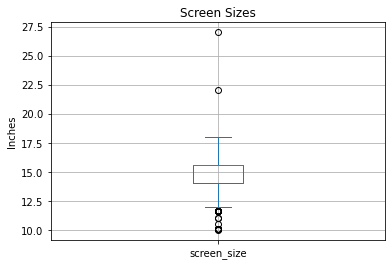

In [262]:
df_d['screen_size'].plot(kind='box')
plt.ylabel('Inches')
plt.title('Screen Sizes')
plt.grid()
plt.show()

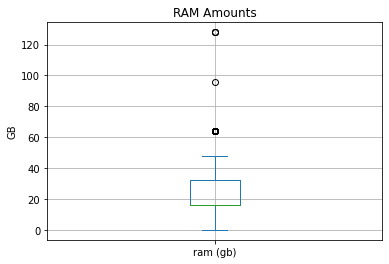

In [263]:
df_d['ram (gb)'].plot(kind='box')
plt.ylabel('GB')
plt.title('RAM Amounts')
plt.grid()
plt.show()

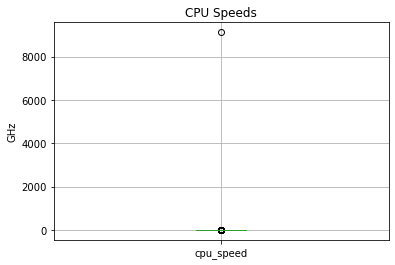

In [264]:
df_d['cpu_speed'].plot(kind='box')
plt.ylabel('GHz')
plt.title('CPU Speeds')
plt.grid()
plt.show()

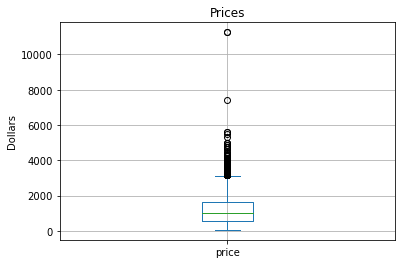

In [265]:
df_d['price'].plot(kind='box')
plt.ylabel('Dollars')
plt.title('Prices')
plt.grid()
plt.show()

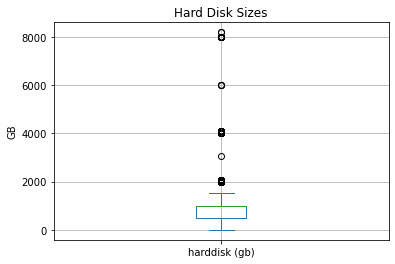

In [266]:
df_d['harddisk (gb)'].plot(kind='box')
plt.ylabel('GB')
plt.title('Hard Disk Sizes')
plt.grid()
plt.show()

In [267]:
df_d['cpu_speed'].loc[df_d['cpu_speed'] > 2000] = np.nan
print(df_d['cpu_speed'])

0      NaN
1      NaN
2      NaN
3      NaN
4      NaN
        ..
4441   NaN
4442   NaN
4443   NaN
4444   NaN
4445   NaN
Name: cpu_speed, Length: 4446, dtype: float64


C:\Users\cavlo\AppData\Local\Temp\ipykernel_13620\2157102070.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_d['cpu_speed'].loc[df_d['cpu_speed'] > 2000] = np.nan


In [268]:
print(df_d.dtypes)

screen_size             float64
cpu                      object
ram (gb)                float64
OS                       object
graphics                 object
graphics_coprocessor     object
cpu_speed               float64
price                   float64
harddisk (gb)           float64
dtype: object


In [269]:
df_d.to_excel('amazon_laptop_2023_cleaned.xlsx')